## 1. Чтение данных

Датасет **Don't Get Kicked!** (Kaggle) - задача бинарной классификации: предсказать, является ли подержанный автомобиль некачественным (целевая переменная `IsBadBuy`).

Импортируем необходимые библиотеки.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from category_encoders import CountEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import average_precision_score
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

In [2]:
train_df = pd.read_csv('data/train.csv')
train_df.head(3)

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389


## 2. Разведывательный анализ данных (EDA)

Прежде чем строить модель, исследуем датасет: посмотрим на распределение целевой переменной, числовые признаки и пропущенные значения.

In [3]:
print(f'Размер датасета: {train_df.shape}')
print(f'\nТипы данных:')
print(train_df.dtypes.value_counts())
print(f'\nПропущенные значения (топ-10):')
print(train_df.isnull().sum().sort_values(ascending=False).head(10))

Размер датасета: (72983, 34)

Типы данных:
object     15
float64    10
int64       9
Name: count, dtype: int64

Пропущенные значения (топ-10):
PRIMEUNIT                            69564
AUCGUART                             69564
WheelType                             3174
WheelTypeID                           3169
Trim                                  2360
MMRCurrentAuctionAveragePrice          315
MMRCurrentRetailCleanPrice             315
MMRCurrentRetailAveragePrice           315
MMRCurrentAuctionCleanPrice            315
MMRAcquisitionAuctionAveragePrice       18
dtype: int64


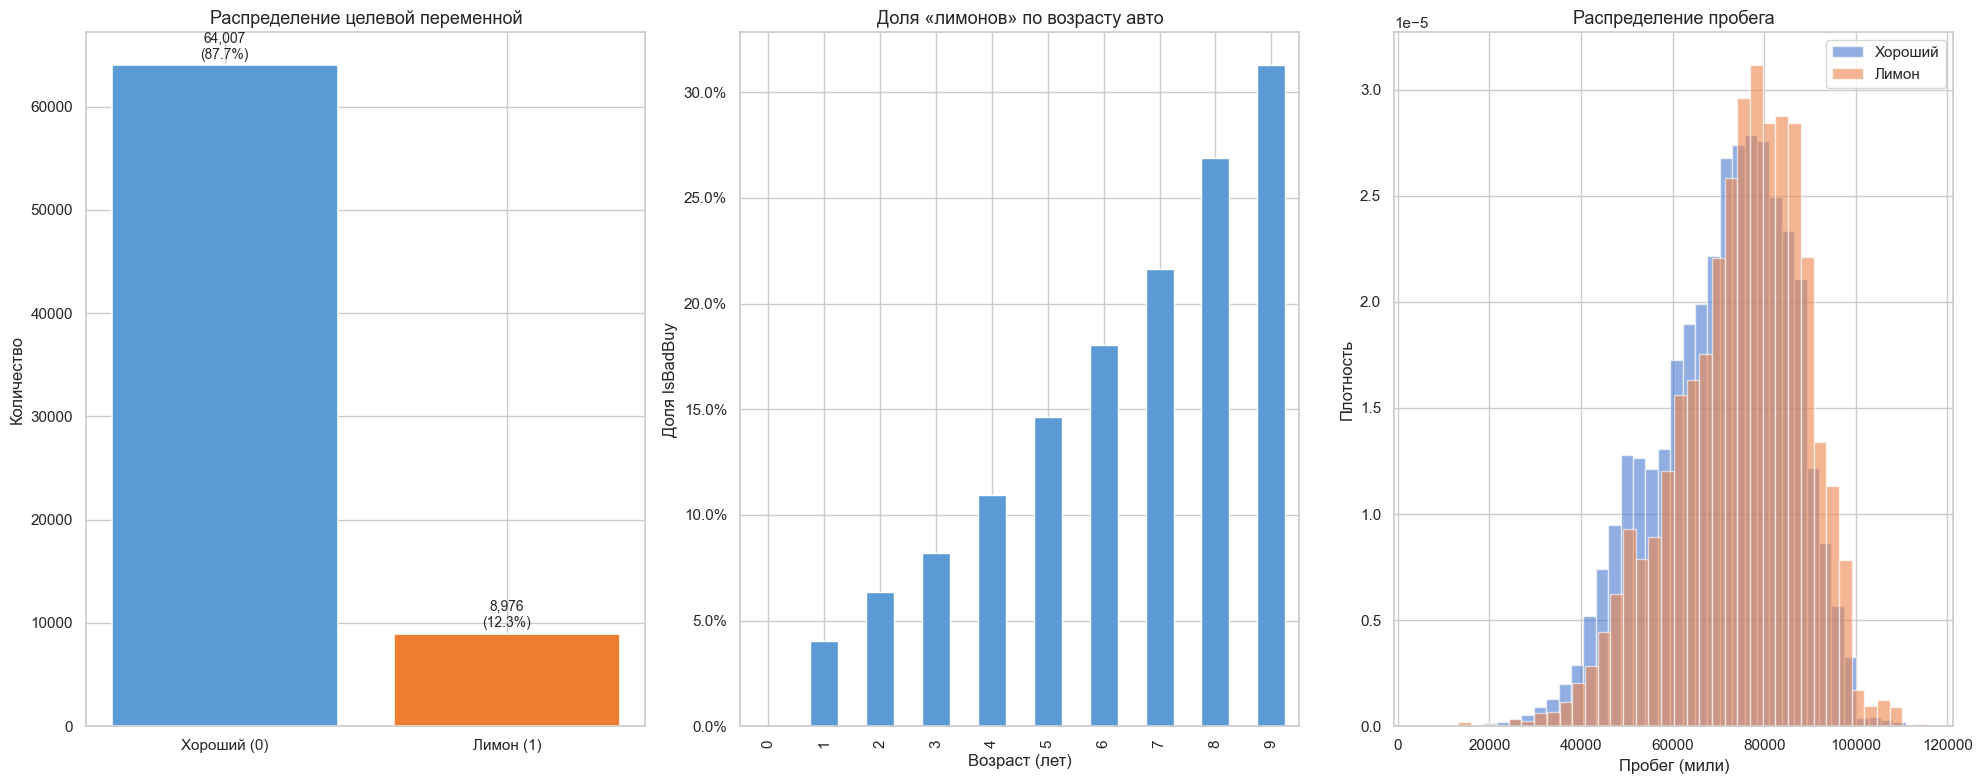

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

target_counts = train_df['IsBadBuy'].value_counts()
axes[0].bar(['Хороший (0)', 'Лимон (1)'], target_counts.values,
            color=['#5b9bd5', '#ed7d31'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Распределение целевой переменной', fontsize=13)
axes[0].set_ylabel('Количество')
for bar, val in zip(axes[0].patches, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}\n({val/len(train_df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)

train_df.groupby('VehicleAge')['IsBadBuy'].mean().plot(
    kind='bar', ax=axes[1], color='#5b9bd5', edgecolor='white')
axes[1].set_title('Доля «лимонов» по возрасту авто', fontsize=13)
axes[1].set_xlabel('Возраст (лет)')
axes[1].set_ylabel('Доля IsBadBuy')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for label, grp in train_df.groupby('IsBadBuy')['VehOdo']:
    axes[2].hist(grp, bins=40, alpha=0.6,
                 label='Лимон' if label == 1 else 'Хороший', density=True)
axes[2].set_title('Распределение пробега', fontsize=13)
axes[2].set_xlabel('Пробег (мили)')
axes[2].set_ylabel('Плотность')
axes[2].legend()

plt.tight_layout()
plt.show()

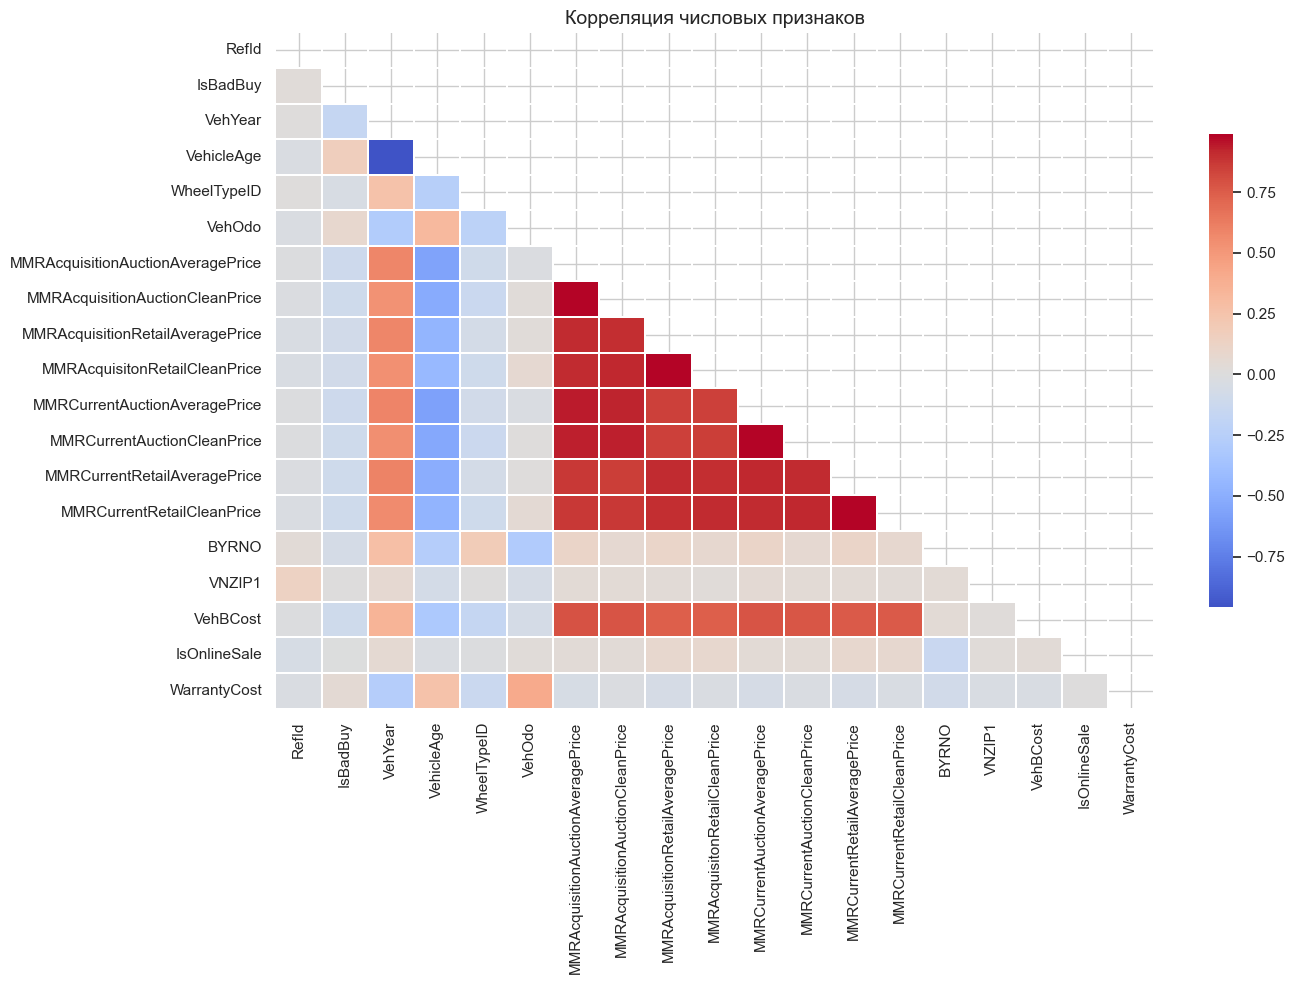

In [5]:
num_cols = train_df.select_dtypes(include='number').columns.tolist()
corr = train_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0,
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Корреляция числовых признаков', fontsize=14)
plt.tight_layout()
plt.show()

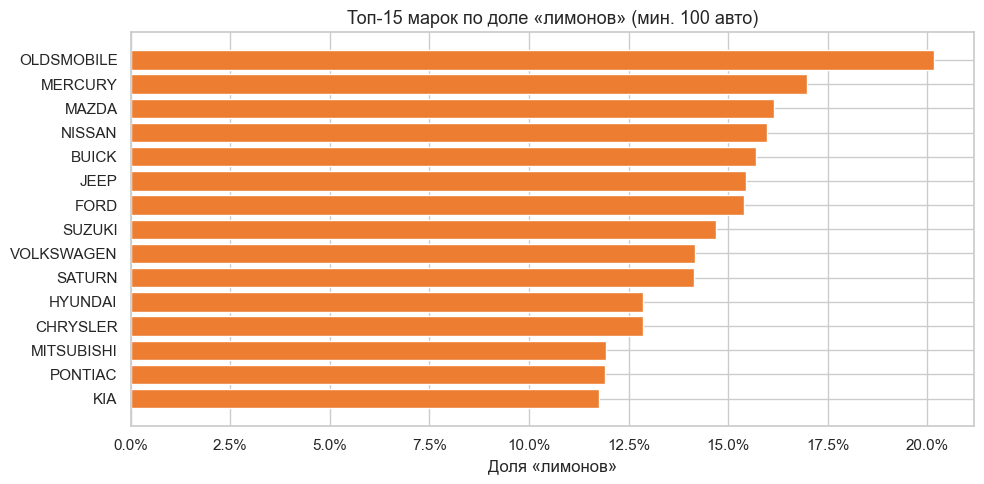

Базовый уровень (base rate): 12.30%


In [6]:
make_stats = train_df.groupby('Make').agg(
    count=('IsBadBuy', 'size'),
    bad_rate=('IsBadBuy', 'mean')
).query('count >= 100').sort_values('bad_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(make_stats.index[::-1], make_stats['bad_rate'][::-1],
               color='#ed7d31', edgecolor='white')
ax.set_xlabel('Доля «лимонов»')
ax.set_title('Топ-15 марок по доле «лимонов» (мин. 100 авто)', fontsize=13)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

print(f'Базовый уровень (base rate): {train_df["IsBadBuy"].mean():.2%}')

## 3. Разделение данных

Разделяем данные по времени, чтобы избежать data leakage: обучение -> валидация -> тест идут последовательно по дате покупки `PurchDate`. Каждая часть занимает треть временного диапазона.

In [7]:
def train_val_test_split(date_col, split_df, target_name='IsBadBuy'):
    df = split_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    unique_dates = sorted(df[date_col].unique())

    fold_size = len(unique_dates) // 3

    train_dates = unique_dates[:fold_size]
    val_dates = unique_dates[fold_size:fold_size*2]
    test_dates = unique_dates[fold_size*2:]   

    X_train = df[df[date_col].isin(train_dates)]
    X_val = df[df[date_col].isin(val_dates)]
    X_test = df[df[date_col].isin(test_dates)]
    
    y_train = X_train[target_name]
    y_val = X_val[target_name]
    y_test = X_test[target_name]

    X_train = X_train.drop(columns=target_name)
    X_val = X_val.drop(columns=target_name)
    X_test = X_test.drop(columns=target_name)

    return X_train, y_train, X_val, y_val, X_test, y_test

In [8]:
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split('PurchDate', train_df)

print(len(X_train), len(X_val), len(X_test))
print(f"Условие выполнено: {X_train['PurchDate'].max() < X_val['PurchDate'].min() \
                            < X_test['PurchDate'].min()}")

23059 24104 25820
Условие выполнено: True


## 4. Обработка категориальных признаков

In [9]:
categor_cols = X_train.select_dtypes(include=['object', 'category'])
categor_cols.head(3)

,Auction,Make,Model,Trim,SubModel,Color,Transmission,WheelType,Nationality,Size,TopThreeAmericanName,PRIMEUNIT,AUCGUART,VNST
426,ADESA,MERCURY,SABLE 3.0L V6 EFI,GS,4D SEDAN GS,MAROON,AUTO,Covers,AMERICAN,MEDIUM,FORD,NaN,NaN,VA
427,ADESA,CHRYSLER,PACIFICA FWD 3.5L V6,Tou,4D SPORT,WHITE,AUTO,Alloy,AMERICAN,CROSSOVER,CHRYSLER,NaN,NaN,VA
428,ADESA,CHEVROLET,IMPALA 3.5L V6 SFI,LS,4D SEDAN LS,GREY,AUTO,Covers,AMERICAN,LARGE,GM,NaN,NaN,VA


In [10]:
unique_counts = categor_cols.nunique()
unique_counts

Auction                   3
Make                     31
Model                   795
Trim                    122
SubModel                650
Color                    16
Transmission              2
WheelType                 3
Nationality               4
Size                     12
TopThreeAmericanName      4
PRIMEUNIT                 1
AUCGUART                  1
VNST                     29
dtype: int64

In [11]:
categor_cols.isnull().sum()

Auction                     0
Make                        0
Model                       0
Trim                      694
SubModel                    8
Color                       8
Transmission                8
WheelType                 872
Nationality                 0
Size                        0
TopThreeAmericanName        0
PRIMEUNIT               23057
AUCGUART                23057
VNST                        0
dtype: int64

Стратегия кодирования категориальных признаков:

- Бинарные (`PRIMEUNIT`, `AUCGUART`) -> 0/1
- Низкая кардинальность (≤ 16 уникальных значений) -> OneHotEncoding
- Высокая кардинальность (> 16) -> CountEncoding (заменяем значение частотой встречаемости)

In [12]:
bin_cols = ['PRIMEUNIT', 'AUCGUART']

onehot_cols = unique_counts[(unique_counts <= 16) &
                            (~unique_counts.index.isin(bin_cols))].index.tolist()
count_cols = unique_counts[unique_counts > 16].index.tolist()

In [13]:
def fill_missing(df):
    df = df.copy()

    df['PRIMEUNIT'] = (df['PRIMEUNIT'] == 'YES').astype(int)
    df['AUCGUART'] = (df['AUCGUART'] == 'GREEN').astype(int)   

    for col in onehot_cols + count_cols:
        df[col] = df[col].fillna("missing")

    return df

X_train = fill_missing(X_train)
X_val = fill_missing(X_val)
X_test = fill_missing(X_test)

In [14]:
hot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_hot = hot_encoder.fit_transform(X_train[onehot_cols])
val_hot = hot_encoder.transform(X_val[onehot_cols])
test_hot = hot_encoder.transform(X_test[onehot_cols])

count_encoder = CountEncoder()
train_cnt = count_encoder.fit_transform(X_train[count_cols])
val_cnt = count_encoder.transform(X_val[count_cols])
test_cnt = count_encoder.transform(X_test[count_cols])

In [15]:
def union_df(df, encoded_df1, encoded_df2):
    onehot_df = pd.DataFrame(encoded_df1, 
                             columns=hot_encoder.get_feature_names_out(onehot_cols), 
                             index=df.index)
    
    final_df = pd.concat([
        df.drop(columns=onehot_cols + count_cols),
        onehot_df,
        encoded_df2
    ], axis=1)

    return final_df

X_train = union_df(X_train, train_hot, train_cnt)
X_val = union_df(X_val, val_hot, val_cnt)
X_test = union_df(X_test, test_hot, test_cnt)

Извлекаем из даты покупки числовые признаки: год, месяц, день, день недели и квартал. Это позволяет модели улавливать сезонные паттерны.

In [16]:
def process_date_col(df, date_column='PurchDate'):
    df = df.copy()

    df['year'] = df[date_column].dt.year
    df['month'] = df[date_column].dt.month
    df['day'] = df[date_column].dt.day
    df['dayofweek'] = df[date_column].dt.dayofweek
    df['quarter'] = df[date_column].dt.quarter

    df = df.drop(columns=date_column)

    return df

X_train = process_date_col(X_train, 'PurchDate')
X_val = process_date_col(X_val, 'PurchDate')
X_test = process_date_col(X_test, 'PurchDate')

In [17]:
missing_cols = train_df.select_dtypes(include=['int64', 'float64']).isnull().sum()
missing_cols = missing_cols[missing_cols != 0].index.to_list()

missing_df = pd.DataFrame()
for i in range(len(missing_cols)):
    missing_df = pd.concat((missing_df, train_df[missing_cols[i]]), axis=1)

missing_df.head()

,WheelTypeID,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice
0,1.0,8155.0,9829.0,11636.0,13600.0,7451.0,8552.0,11597.0,12409.0
1,1.0,6854.0,8383.0,10897.0,12572.0,7456.0,9222.0,11374.0,12791.0
2,2.0,3202.0,4760.0,6943.0,8457.0,4035.0,5557.0,7146.0,8702.0
3,1.0,1893.0,2675.0,4658.0,5690.0,1844.0,2646.0,4375.0,5518.0
4,2.0,3913.0,5054.0,7723.0,8707.0,3247.0,4384.0,6739.0,7911.0


In [18]:
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train['WheelTypeID'] = imputer_cat.fit_transform(X_train[['WheelTypeID']])
X_val['WheelTypeID'] = imputer_cat.transform(X_val[['WheelTypeID']])
X_test['WheelTypeID'] = imputer_cat.transform(X_test[['WheelTypeID']])

missing_cols.remove('WheelTypeID')
imputer_num = SimpleImputer(strategy='median')
X_train[missing_cols] = imputer_cat.fit_transform(X_train[missing_cols])
X_val[missing_cols] = imputer_cat.transform(X_val[missing_cols])
X_test[missing_cols] = imputer_cat.transform(X_test[missing_cols])

## 5. Базовые модели (sklearn)

In [19]:
base_cols = X_train.columns.to_list()
no_scale_cols = onehot_cols + bin_cols
scale_cols = [col for col in base_cols if col not in no_scale_cols]

Нормализуем только числовые и count-encoded признаки. OneHot-признаки и бинарные флаги уже в нужном диапазоне - их масштабировать не нужно.

In [20]:
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_val[scale_cols] = scaler.transform(X_val[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [21]:
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)
val_pred_lr = logreg.predict_proba(X_val)[:,1]

In [22]:
gnb = GaussianNB()

gnb.fit(X_train, y_train)
val_pred_gnb = gnb.predict_proba(X_val)[:,1]

In [23]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)
val_pred_knn = knn.predict_proba(X_val)[:,1]

In [24]:
def gini_sklearn(y_true, y_proba):
    return 2 * roc_auc_score(y_true, y_proba) - 1

gini_lr = gini_sklearn(y_val, val_pred_lr)
gini_gnb = gini_sklearn(y_val, val_pred_gnb)
gini_knn = gini_sklearn(y_val, val_pred_knn)

print(f"LogisticRegression: {gini_lr}\nGaussianNB: {gini_gnb}\nKNeighborsClassifier: {gini_knn}")

LogisticRegression: 0.37769383736596995
GaussianNB: 0.42041845338914907
KNeighborsClassifier: 0.31216322528355467


Сравниваем baseline - качество трёх алгоритмов по метрике **Gini** (= 2·AUC−1). Gini = 0 означает случайное угадывание, Gini = 1 - идеальный классификатор.

Лучшим алгоритмом оказался - GaussianNB. 

1. Работает хорошо с категориальными признаками после кодирования

* Признаки после OneHotEncoder и CountEncoder создали разреженное пространство

* Наивный Байес хорошо справляется с разреженными данными

2. Меньше подвержен переобучению

* KNN (0.313) сильнее зависит от выбора k и чувствителен к шуму

* Logistic Regression (0.388) хорош, но требует больше тюнинга

3. Эффективно работает с признаками разной природы

* Смесь: бинарные (OneHot, PRIMEUNIT), частотные (CountEncoder), числовые (цены)

* GaussianNB предполагает независимость признаков

## 6. Собственная реализация Gini

Реализуем Gini через AUC-ROC, используя алгоритм **Wilcoxon-Mann-Whitney**: для каждой позитивной пары (pos, neg) считаем ранги без явной сортировки всех пар. Сложность: **O(n log n)** за счёт единственной сортировки.

Формула: `Gini = 2 · AUC − 1`

In [25]:
def my_gini(y_true, y_proba):
    def roc_auc(y_true, y_proba):
        pairs = sorted(zip(y_proba, y_true), key=lambda x: x[0], reverse=True)

        n_pos = sum(y_true)
        n_neg = len(y_true) - n_pos

        ranks_pos_sum = 0
        for i, (_, y) in enumerate(pairs, 1):
            if y == 1:
                ranks_pos_sum += i

        auc = (ranks_pos_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
        return auc
    
    return abs(2 * roc_auc(y_true, y_proba) - 1)

gini_lr = my_gini(y_val, val_pred_lr)
gini_gnb = my_gini(y_val, val_pred_gnb)
gini_knn = my_gini(y_val, val_pred_knn)

print(f"LogisticRegression: {gini_lr}\nGaussianNB: {gini_gnb}\nKNeighborsClassifier: {gini_knn}")

LogisticRegression: 0.37769383736596995
GaussianNB: 0.42011755372094983
KNeighborsClassifier: 0.32693760214123935


Результаты схожи с sklearn

## 7. Собственная реализация моделей

### Логистическая регрессия (SGD)

Реализация с **стохастическим градиентным спуском (SGD)** и L2-регуляризацией. На каждой итерации данные перемешиваются и обновление весов происходит по одному примеру.

In [26]:
class LogisticReg:
    def __init__(self, learning_rate=0.01, n_iter=1000, c=1, random_state=42):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.c = c
        self.random_state = random_state
        self.bias = None
        self.w = None
        if random_state is not None:
            np.random.seed(random_state)

    def _sigmoid(self, func):
        return 1/(1+np.exp(-func))
    
    def fit(self, X, y):
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        m, n = X.shape
        self.w = np.random.randn(n) * 0.01
        self.bias = 0

        reg = 1 / self.c

        for i in range(self.n_iter):
            indx = np.random.permutation(m)
            X_shuffle = X[indx]
            y_shuffle = y[indx]

            for j in range(m):
                X_sgd = X_shuffle[j]
                y_sgd = y_shuffle[j]

                z = np.dot(X_sgd, self.w) + self.bias
                p = self._sigmoid(z)

                error = p - y_sgd

                dw = X_sgd * error + reg * self.w
                db = error

                self.w -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.w) + self.bias)
    
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [27]:
my_log_reg = LogisticReg()
my_log_reg.fit(X_train, y_train)

log_proba = my_log_reg.predict_proba(X_val)
gini_my_lr = my_gini(y_val, log_proba)

### K-Nearest Neighbors

Реализация через евклидово расстояние. Вероятность класса 1 - доля единиц среди k ближайших соседей.

In [28]:
class KNN:
    def __init__(self, k):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict_proba(self, X):
        X = np.array(X)
        probabilities = []
        for x in X:
            dist = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            neighbors_idx = np.argsort(dist)[:self.k]
            neighbor_labels = self.y_train[neighbors_idx]
            proba = np.mean(neighbor_labels)
            probabilities.append(proba)
        return probabilities

    def predict(self, X, threshold=0.5):
        proba = np.array(self.predict_proba(X))
        return (proba >= threshold).astype(int)

In [29]:
my_knn = KNN(k=5)
my_knn.fit(X_train, y_train)

knn_proba = my_knn.predict_proba(X_val)
gini_my_knn = my_gini(y_val, knn_proba)

### Наивный Байес (Gaussian NB)

Реализация предполагает нормальное распределение каждого признака в каждом классе. Предсказание - через лог-вероятности (log-sum-exp trick для численной устойчивости).

In [30]:
class NaiveBayes:
    def __init__(self):
        self.class_prior = {}
        self.classes = None
        self.means = {}
        self.variances = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            X_c = X[y == c]
            self.class_prior[c] = len(X_c) / len(X)
            self.means[c] = X_c.mean(axis=0)
            self.variances[c] = X_c.var(axis=0) + 1e-9
        return self
    
    def _gaussian_dens(self, x, mean, var):
        return -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)

    def predict_proba(self, X):
        X = np.array(X)
        probabilities = []
        for x in X:
            scores = {}
            for c in self.classes:
                log_prior = np.log(self.class_prior[c])
                log_likelihood = np.sum(self._gaussian_dens(x, self.means[c], self.variances[c]))
                scores[c] = log_prior + log_likelihood

            max_score = max(scores.values())
            exp_scores = {c: np.exp(scores[c] - max_score) for c in scores}
            total = sum(exp_scores.values())

            proba = exp_scores[1] / total
            probabilities.append(proba)
        return probabilities
    
    def predict(self, X, threshold=0.5):
        proba = np.array(self.predict_proba(X))
        return (proba >= threshold).astype(int)

In [31]:
my_nb = NaiveBayes()
my_nb.fit(X_train, y_train)

nb_proba = my_nb.predict_proba(X_val)
gini_my_nb = my_gini(y_val, nb_proba)

In [32]:
print(f"LogisticRegression sklearn: {gini_lr}; my: {gini_my_lr}")
print(f"GaussianNB sklearn: {gini_gnb}; my: {gini_my_nb}")
print(f"KNeighborsClassifier sklearn: {gini_knn}; my: {gini_my_knn}")

LogisticRegression sklearn: 0.37769383736596995; my: 0.35251957091384667
GaussianNB sklearn: 0.42011755372094983; my: 0.4204102676753796
KNeighborsClassifier sklearn: 0.32693760214123935; my: 0.32693760214123935


## 8. Feature Engineering

Создаём новые признаки на основе доменного понимания задачи:

- Ценовые отношения - соотношения текущих и исторических цен (отражают рыночный тренд)
- Износ - произведение возраста на пробег (`VehicleAge × VehOdo`)
- Интенсивность использования - пробег за год (`VehOdo / (VehicleAge + 1)`)
- Ценовой разрыв - разница между розничной и аукционной ценой
- Статистики по марке - средняя цена и популярность марки

In [33]:
class FeatureEngineer:
    
    def fit(self, X):
        self.make_mean_price = X.groupby("Make")["MMRCurrentRetailAveragePrice"].mean()
        self.make_count = X["Make"].value_counts()
        
        return self
    
    
    def transform(self, X):
        X = X.copy()
        
        # отношения цен
        X['current_to_acquisition'] = (X['MMRCurrentAuctionAveragePrice'] /
            (X['MMRAcquisitionAuctionAveragePrice'] + 1e-9))
        
        X['clean_to_avg'] = (X['MMRCurrentRetailCleanPrice'] /
            (X['MMRCurrentRetailAveragePrice'] + 1e-9))
        
        # износ машины
        X['wear_index'] = X['VehicleAge'] * X['VehOdo']
        
        # интенсивность использования
        X['odo_per_year'] = X['VehOdo'] / (X['VehicleAge'] + 1)
        
        # разница цены 
        X['price_gap'] = (X['MMRCurrentRetailAveragePrice'] -
            X['MMRAcquisitionAuctionAveragePrice'])
        
        # статистики по марке
        X['avg_price_by_make'] = X['Make'].map(self.make_mean_price)
        X['make_popularity'] = X['Make'].map(self.make_count)
        
        X['avg_price_by_make'] = X['avg_price_by_make'].fillna(
            self.make_mean_price.mean()
        )
        
        X['make_popularity'] = X['make_popularity'].fillna(0)
        
        return X
    
fe = FeatureEngineer()
fe.fit(X_train)

X_train_new = fe.transform(X_train)
X_val_new = fe.transform(X_val)
X_test_new = fe.transform(X_test)

log_reg = LogisticRegression(max_iter=10000)

log_reg.fit(X_train_new, y_train)
val_pred_lr = log_reg.predict_proba(X_val_new)[:,1]

gnb = GaussianNB()

gnb.fit(X_train_new, y_train)
val_pred_gnb = gnb.predict_proba(X_val_new)[:,1]

knn = KNeighborsClassifier()

knn.fit(X_train_new, y_train)
val_pred_knn = knn.predict_proba(X_val_new)[:,1]

gini_new_features_lr = gini_sklearn(y_val, val_pred_lr)
gini_new_features_gnb = gini_sklearn(y_val, val_pred_gnb)
gini_new_features_knn = gini_sklearn(y_val, val_pred_knn)

print(f"Результат с новыми признаками:\nLogisticRegression: {gini_new_features_lr};\
      \nGaussianNB: {gini_new_features_gnb};\nKNeighborsClassifier: {gini_new_features_knn}")

Результат с новыми признаками:
LogisticRegression: 0.4031659263749119;      
GaussianNB: 0.4216891360775281;
KNeighborsClassifier: 0.29433133495861585


Feature Engineering дал заметный прирост качества. Посмотрим на коэффициенты логистической регрессии, чтобы понять, какие признаки наиболее важны.

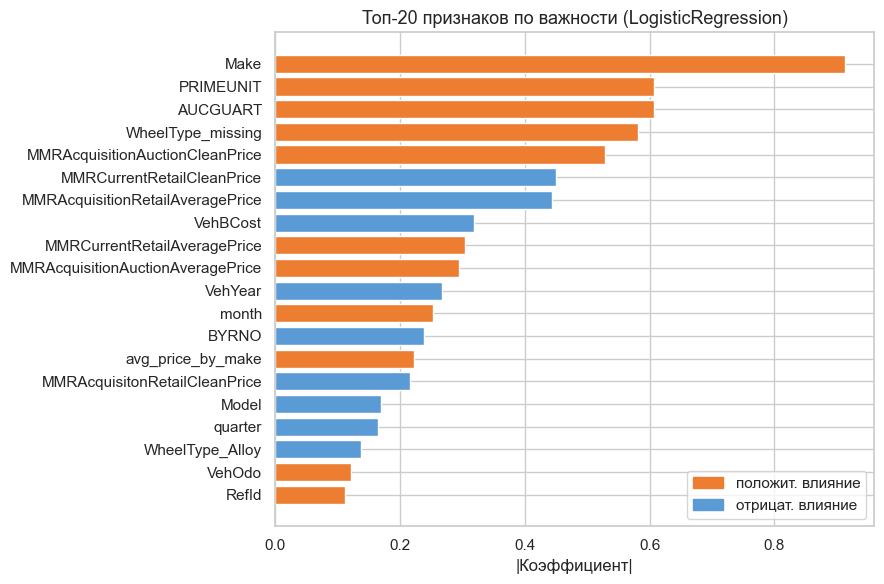

In [34]:
coeff_viz = pd.Series(log_reg.coef_[0], index=X_train_new.columns)
top_feats = coeff_viz.abs().nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#ed7d31' if coeff_viz[f] > 0 else '#5b9bd5' for f in top_feats.index]
ax.barh(top_feats.index, top_feats.values, color=colors, edgecolor='white')
ax.set_xlabel('|Коэффициент|')
ax.set_title('Топ-20 признаков по важности (LogisticRegression)', fontsize=13)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#ed7d31', label='положит. влияние'),
                   Patch(color='#5b9bd5', label='отрицат. влияние')])
plt.tight_layout()
plt.show()

## 9. Отбор признаков 

### Ручной порог по коэффициентам

Удаляем признаки, абсолютный коэффициент которых составляет менее 1% от максимального. Это грубый, но быстрый способ избавиться от слабых предикторов.

In [35]:
coeff = pd.Series(np.abs(log_reg.coef_[0]), index=X_train_new.columns)
max_coeff = coeff.values.max()
threshold = max_coeff * 0.01
weak_features = list(coeff[coeff < threshold].index)
X_train_hand = X_train_new.drop(columns=weak_features)
X_val_hand = X_val_new.drop(columns=weak_features)

log_reg = LogisticRegression(max_iter=10000)

log_reg.fit(X_train_hand, y_train)
val_pred_lr = log_reg.predict_proba(X_val_hand)[:,1]
gini_hand_select_lr = gini_sklearn(y_val, val_pred_lr)

### L1-регуляризация (Lasso)

L1-штраф автоматически зануляет коэффициенты слабых признаков. Используем `penalty='l1'` с `solver='liblinear'`.

In [36]:
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=10000)
logreg_l1.fit(X_train_new, y_train)

coeff_l1 = pd.Series(logreg_l1.coef_[0], index=X_train_new.columns)
weak_features_l1 = coeff_l1[coeff_l1 != 0].index
X_train_l1 = X_train_new[weak_features_l1]
X_val_l1 = X_val_new[weak_features_l1]
X_test_l1 = X_test_new[weak_features_l1]

log_reg = LogisticRegression(max_iter=10000)

log_reg.fit(X_train_l1, y_train)
val_pred_lr = log_reg.predict_proba(X_val_l1)[:,1]
gini_selectl1_lr = gini_sklearn(y_val, val_pred_lr)

In [37]:
print(gini_hand_select_lr)
print(gini_selectl1_lr)

0.36429654253823407
0.347023431740102


## 10. Оптимизация гиперпараметров

Используем **Optuna** для поиска оптимальных гиперпараметров логистической регрессии. Метрика оптимизации - AUC-ROC на 5-fold стратифицированной кросс-валидации.

Пространство поиска:
- `C` - сила регуляризации (лог-равномерно от 0.01 до 10)
- `penalty` - тип регуляризации (L1 / L2)
- `solver` - алгоритм оптимизации (liblinear / saga)
- `class_weight` - учёт дисбаланса классов

In [38]:
def objective_lr(trial):
    C = trial.suggest_float('C', 0.01, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
    solver = trial.suggest_categorical('solver', ['liblinear', 'saga'])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    
    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=5000, 
                               class_weight=class_weight, random_state=42, n_jobs=-1)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train_new, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    
    return scores.mean()

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

best_params_lr = study_lr.best_params
best_roc_auc_lr = study_lr.best_value
best_gini_lr = 2 * best_roc_auc_lr - 1

print(f"Лучшие параметры:{best_params_lr}\nGini: {best_gini_lr}")

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n

Лучшие параметры:{'C': 0.7112746361884157, 'penalty': 'l2', 'solver': 'liblinear', 'class_weight': 'balanced'}
Gini: 0.4982323257241883


In [39]:
best_lr = LogisticRegression(**best_params_lr, random_state=42, n_jobs=-1)
best_lr.fit(X_train_new, y_train)

val_pred_lr = best_lr.predict_proba(X_val_new)[:, 1]
gini_val_lr = gini_sklearn(y_val, val_pred_lr)

print(f"Gini на валидации: {gini_val_lr:.6f}")

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1305: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 8.
  warnings.warn(


Gini на валидации: 0.352811


## 11. Финальная проверка

Финальная оценка лучшей модели на трёх выборках. Важно убедиться, что **Gini на тесте** близок к валидационному - это свидетельствует об отсутствии переобучения.

In [40]:
train_pred = best_lr.predict_proba(X_train_new)[:, 1]
gini_train_lr = gini_sklearn(y_train, train_pred)
test_pred = best_lr.predict_proba(X_test_new)[:, 1]
gini_test_lr = gini_sklearn(y_test, test_pred)

print(f"Train Gini: {gini_train_lr}\nVal Gini: {gini_val_lr}\nTest Gini: {gini_test_lr}")

Train Gini: 0.5217962801709373
Val Gini: 0.35281076125002
Test Gini: 0.4280500903453479


## 12. Собственная реализация метрик

In [41]:
def recall(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))

    if TP + FN == 0:
        return 0
    
    return TP/(TP + FN)

In [42]:
def precision(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))

    if TP + FP == 0:
        return 0
    
    return TP/(TP + FP)

In [43]:
def score_f1(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)

    if p + r == 0:
        return 0
    
    return 2 * (p * r) / (p + r)

In [44]:
def auc_pr(y_true, y_proba):
    thresholds = sorted(set(y_proba), reverse=True)
    
    precision_list = []
    recall_list = []
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        p = precision(y_true, y_pred)
        r = recall(y_true, y_pred)
        
        precision_list.append(p)
        recall_list.append(r)
    
    precision_list = [1.0] + precision_list
    recall_list = [0.0] + recall_list
    
    auc = 0
    for i in range(1, len(recall_list)):
        auc += (precision_list[i] + precision_list[i-1]) * \
               (recall_list[i] - recall_list[i-1]) / 2
    
    return auc

In [45]:
sklearn_auc = average_precision_score(y_test, test_pred)
my_auc = auc_pr(y_test, test_pred)

print(sklearn_auc)
print(my_auc)

0.381763233287639
0.3815383503867656


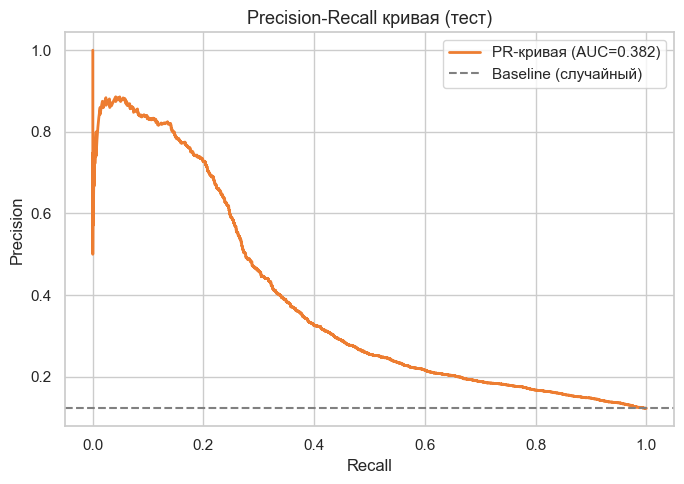

In [46]:
thresholds_plot = sorted(set(test_pred), reverse=True)
pr_list, rec_list = [], []
for thr in thresholds_plot:
    y_pred_thr = (test_pred >= thr).astype(int)
    pr_list.append(precision(y_test, y_pred_thr))
    rec_list.append(recall(y_test, y_pred_thr))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec_list, pr_list, color='#ed7d31', linewidth=2, label=f'PR-кривая (AUC={my_auc:.3f})')
ax.axhline(y=train_df['IsBadBuy'].mean(), color='grey', linestyle='--', label='Baseline (случайный)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривая (тест)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Выбор метрики для жёстких меток

Для задачи выявления «плохих» автомобилей оптимальной метрикой с жёсткими метками является **Recall**.

Почему Recall:
- Пропуск бракованного автомобиля (False Negative) = финансовые потери для дилера
- Ложная тревога (False Positive) менее критична - машину просто не купят
- Асимметричная стоимость ошибок диктует приоритет полноты покрытия

Когда предпочесть F1:
- Если ресурсы на проверку ограничены и важно не тратить их впустую (баланс Precision и Recall)

> **Вывод:** в условиях данной задачи - **Recall**. При более строгом бюджете проверок - **F1**.